<a href="https://colab.research.google.com/github/eshwarjyEnder-Cyber/Ender/blob/main/1_CNN_Assg_Waste_Segregation_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [ ]:
# Import essential libraries

#!pip install ml_dtypes>=0.5
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import PIL
from PIL import Image
#!pip install --upgrade ml_dtypes
#!pip install ml-dtypes==0.4.1
#!pip install tensorflow==2.20.0
#!pip install keras==3.13.2
import tensorflow as tf
import keras as ker
import sklearn as skl

print('numpy version:', np.__version__)
print('pandas version:', pd.__version__)
print('seaborn version:', sns.__version__)
print('matplotlib version:', plt.matplotlib.__version__)
print('PIL version:', PIL.__version__)
print('tensorflow version:', tf.__version__)
print('keras version:', ker.__version__)
print('sklearn version:', skl.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
seaborn version: 0.13.2
matplotlib version: 3.10.0
PIL version: 11.3.0
tensorflow version: 2.20.0
keras version: 3.13.2
sklearn version: 1.6.1


Load the dataset.

In [ ]:
# Load and unzip the dataset
import os
import zipfile

# Define data_path
df_zip= "/content/data.zip"
df = '/content/data_set'

# Unzip the data set
with zipfile.ZipFile(df_zip, 'r') as zip_ref:
  zip_ref.extractall(df)
  print('Done')

# Check available categories
print('Available Categories:', os.listdir(df))

data_path = os.path.join(df, "data")
print("Subfolders (classes):", os.listdir(df))


Done
Available Categories: ['data']
Subfolders (classes): ['data']


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [ ]:

# Create a function to load the raw images
import numpy as np
from PIL import Image

def load_images_from_folders(folder_path, label, target_size= (128, 128)):
  images = []
  labels = []

  for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)
    try:
      # Open image
      img = Image.open(file_path).convert('RGB')
      # Resize image
      img = img.resize(target_size)
      # Convert to numpy array
      img_array = np.array(img)
      images.append(img_array)
      labels.append(label)
    except Exception as e:
      print(f"Error Loading image {file_path}:,{e}")
  return images, labels


#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [ ]:

#import numpy as np
# Get the images and their labels

dataset_path = "/content/data_set/data"

# Get the categories (subfolders inside dataset_path)
categories = os.listdir(dataset_path)
print("Categories found:", categories)

all_images, all_labels = [], []
for category in categories:
  folder = os.path.join(dataset_path, category)
  imgs, lbls = load_images_from_folders(folder, category)
  all_images.extend(imgs)
  all_labels.extend(lbls)

print(f"Total images loaded: {len(all_images)}")
print(f"Total labels loaded: {len(all_labels)}")

# Convert to numpy array
try:
  X = np.array(all_images)
  Y = np.array(all_labels)
  print('Correct images loaded:', X.shape)
  print('Correct labels loaded:', Y.shape)
  print('Sample images:', X[:10])
  print('Sample labels:', Y[:10])
except Exception as e:
  print(f"Error converting to numpy array: {e}")



Categories found: ['Other', 'Metal', 'Paper', 'Plastic', 'Cardboard', 'Food_Waste', 'Glass']
Total images loaded: 7625
Total labels loaded: 7625
Correct images loaded: (7625, 128, 128, 3)
Correct labels loaded: (7625,)
Sample images: [[[[ 65  37  34]
   [ 65  38  34]
   [ 63  39  34]
   ...
   [160 132  98]
   [164 134 100]
   [165 135 101]]

  [[ 67  38  33]
   [ 67  39  34]
   [ 66  40  35]
   ...
   [157 132  99]
   [158 132  99]
   [159 132 100]]

  [[ 69  39  33]
   [ 69  40  34]
   [ 69  42  35]
   ...
   [146 123  92]
   [143 119  89]
   [141 116  87]]

  ...

  [[173 143 125]
   [172 142 124]
   [175 144 126]
   ...
   [199 180 164]
   [200 179 163]
   [199 178 160]]

  [[176 147 128]
   [172 144 124]
   [176 147 128]
   ...
   [196 177 162]
   [195 176 160]
   [193 174 157]]

  [[184 159 137]
   [184 158 137]
   [184 158 136]
   ...
   [194 177 161]
   [193 176 159]
   [195 177 160]]]


 [[[166 163 148]
   [167 166 144]
   [169 165 139]
   ...
   [161 145 125]
   [161 147 130]

Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

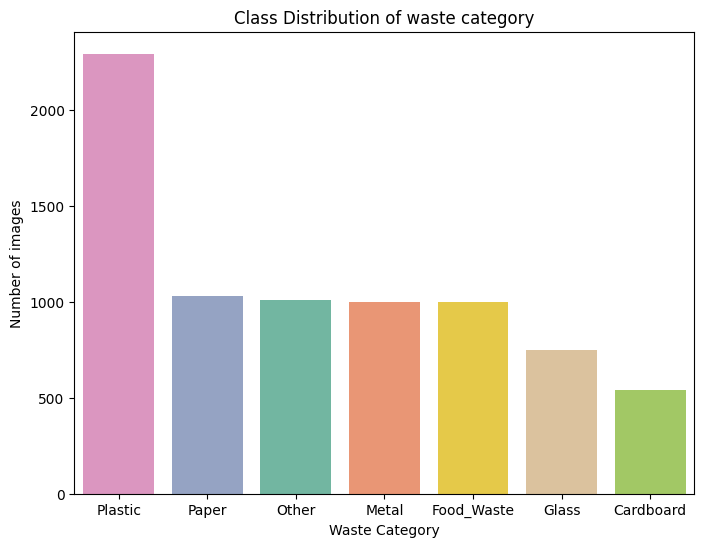

In [ ]:
# Visualise Data Distribution
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the labels to a DataFrame

labels_df = pd.DataFrame(Y, columns = ['Category'])

plt.figure(figsize= (8, 6))
sns.countplot(data = labels_df, x = 'Category', hue = 'Category', order = labels_df['Category'].value_counts().index, palette = 'Set2', legend=False)
plt.title('Class Distribution of waste category')
plt.xlabel('Waste Category')
plt.ylabel('Number of images')
plt.show()


#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

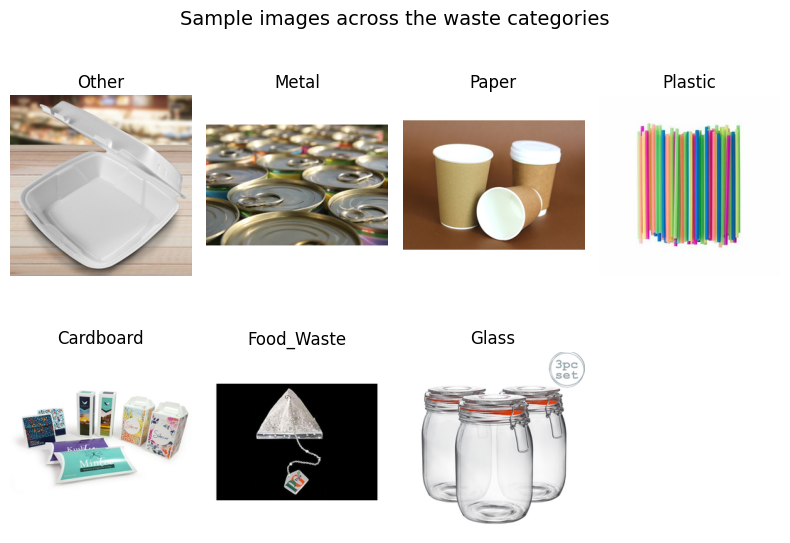

In [ ]:
# Visualise Sample Images (across different labels)
plt.figure(figsize=(8, 6))

# Display one sample image for one category
for i, category in enumerate(categories[:7]):          # Limit to 7 categories
  folder = os.path.join(dataset_path, category)
  sample_image = os.listdir(folder)[0]                 # Pick the first image
  img_path = os.path.join(folder, sample_image)

  img = Image.open(img_path)
  plt.subplot(2, 4, i+1)
  plt.imshow(img)
  plt.title(category)
  plt.axis('off')

plt.suptitle('Sample images across the waste categories', fontsize = 14)
plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [ ]:
# Find the smallest and largest image dimensions from the data set

# initialize list to store dimensions
widths, heights = [], []

# Loop through all the categories and images
for category in categories:
  folder = os.path.join(dataset_path, category)
  for filename in os.listdir(folder):
    file_path = os.path.join(folder, filename)
    try:
      img = Image.open(file_path)
      w, h = img.size
      widths.append(w)
      heights.append(h)
    except Exception as e:
      print(f"Error skipping {file_path}: {e}")

# Find smallest and largest dimensions
min_width, max_width = min(widths), max(widths)
min_height, max_height = min(heights), max(heights)

print(f"Smallest image dimensions: {min_width} * {min_height}")
print(f"Largest image dimensions: {max_width} * {max_height}")


Smallest image dimensions: 256 * 256
Largest image dimensions: 256 * 256


In [ ]:
# Resize the image dimensions
# Define target size
target_size = (128, 128)

# Resize image
def resize_image(images, target_size):
  resized_image = []
  for img_array in images:
    img = Image.fromarray(img_array)
    img = img.resize(target_size)
    resized_image.append(np.array(img))
  return np.array(resized_image)

# Apply resizing
X_resized = resize_image(all_images, target_size)

print('Resized images:', X_resized.shape)


Resized images: (7625, 128, 128, 3)


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [ ]:
# Encode the labels suitably

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode string labels to integer
Label_encoder = LabelEncoder()
Y_encoded = Label_encoder.fit_transform(Y)

print("Integr encoded labels (first 10):", Y_encoded[:10])
print("Classes :", Label_encoder.classes_)

# Convert to One-hot encoding
Y_onehot = to_categorical(Y_encoded)

print("One-hot encoded labels shape:", Y_onehot.shape)
print("One-hot sample first (first 5):\n", Y_onehot[:5] )


Integr encoded labels (first 10): [4 4 4 4 4 4 4 4 4 4]
Classes : ['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']
One-hot encoded labels shape: (7625, 7)
One-hot sample first (first 5):
 [[0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]]


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [ ]:
# Assign specified parts of the dataset to train and validation sets
from sklearn.model_selection import train_test_split

# Normalize the pixel values
X_normalized = X_resized.astype('float32') / 255.0

# Split dataset (80% train, 20% test)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_normalized,
    Y_onehot,
    test_size = 0.2,
    random_state = 42,
    stratify = Y_encoded
)

print("Training set :", X_train.shape, Y_train.shape)
print('Validation set:', X_val.shape, Y_val.shape )


Training set : (6100, 128, 128, 3) (6100, 7)
Validation set: (1525, 128, 128, 3) (1525, 7)


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [ ]:
# Build and compile the model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Build the CNN model
model = Sequential([
    # Convolutional Block 1
    Conv2D(32, (3,3), activation = 'relu', input_shape = (128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    # Convolutional Block 2
    Conv2D(64, (3,3), activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    # Convolutional Block 3
    Conv2D(128, (3,3), activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    # Flatten and Dense Layers
    Flatten(),
    Dense(256, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(7, activation = 'softmax')    # 7 Classes
])

# Compile the model
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

# Summary
model.summary()





Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,519,751 (24.87 MB)

 Trainable params: 6,518,791 (24.87 MB)

 Non-trainable params: 960 (3.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [ ]:
# Training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define callbacks
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor = 'val_accuracy',
    save_best_only = True,
    mode = 'max'
)

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.2,
    patience = 3,
    min_lr=1e-5
)

# Train the model
history = model.fit(
    X_train, Y_train,
    epochs = 30,
    batch_size = 32,
    validation_data = (X_val, Y_val),
    callbacks = [early_stop, checkpoint, reduce_lr],
    verbose = 1
)



Epoch 1/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2909 - loss: 2.3624

191/191 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.3248 - loss: 2.0921 - val_accuracy: 0.1351 - val_loss: 2.5099 - learning_rate: 0.0010
Epoch 2/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4154 - loss: 1.6850

191/191 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.4323 - loss: 1.6233 - val_accuracy: 0.3495 - val_loss: 2.0709 - learning_rate: 0.0010
Epoch 3/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 496s 3s/step - accuracy: 0.5018 - loss: 1.4281 - val_accuracy: 0.3089 - val_loss: 2.0515 - learning_rate: 0.0010
Epoch 4/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5451 - loss: 1.2838

191/191 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.5452 - loss: 1.2750 - val_accuracy: 0.3561 - val_loss: 2.1378 - learning_rate: 0.0010
Epoch 5/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5952 - loss: 1.1478

191/191 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.5967 - loss: 1.1336 - val_accuracy: 0.4616 - val_loss: 1.5203 - learning_rate: 0.0010
Epoch 6/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6408 - loss: 0.9893

...

191/191 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.8603 - loss: 0.4406 - val_accuracy: 0.6269 - val_loss: 1.2539 - learning_rate: 2.0000e-04
Epoch 13/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8778 - loss: 0.3774

191/191 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8838 - loss: 0.3706 - val_accuracy: 0.6452 - val_loss: 1.1705 - learning_rate: 2.0000e-04
Epoch 14/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.8900 - loss: 0.3414 - val_accuracy: 0.6321 - val_loss: 1.2125 - learning_rate: 2.0000e-04
Epoch 15/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.9089 - loss: 0.2961 - val_accuracy: 0.6433 - val_loss: 1.1915 - learning_rate: 2.0000e-04
Epoch 16/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.9167 - loss: 0.2747 - val_accuracy: 0.6439 - val_loss: 1.1392 - learning_rate: 2.0000e-04
Epoch 17/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9284 - loss: 0.2324

191/191 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.9334 - loss: 0.2311 - val_accuracy: 0.6570 - val_loss: 1.1804 - learning_rate: 2.0000e-04
Epoch 18/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9457 - loss: 0.1974

191/191 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.9385 - loss: 0.2111 - val_accuracy: 0.6616 - val_loss: 1.2347 - learning_rate: 2.0000e-04
Epoch 19/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.9459 - loss: 0.1860 - val_accuracy: 0.6577 - val_loss: 1.3196 - learning_rate: 2.0000e-04
Epoch 20/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.9543 - loss: 0.1672 - val_accuracy: 0.6577 - val_loss: 1.2249 - learning_rate: 4.0000e-05
Epoch 21/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9625 - loss: 0.1609

191/191 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.9593 - loss: 0.1589 - val_accuracy: 0.6623 - val_loss: 1.2355 - learning_rate: 4.0000e-05


### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 306ms/step - accuracy: 0.6439 - loss: 1.1392
Test Accuracy: 0.6439
Test loss: 1.1392
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 294ms/step
Classification Report:

              precision    recall  f1-score   support

   Cardboard       0.69      0.77      0.73       108
  Food_Waste       0.63      0.74      0.69       200
       Glass       0.44      0.67      0.53       150
       Metal       0.68      0.65      0.66       200
       Other       0.55      0.59      0.57       202
       Paper       0.70      0.47      0.56       206
     Plastic       0.77      0.67      0.71       459

    accuracy                           0.64      1525
   macro avg       0.64      0.65      0.63      1525
weighted avg       0.66      0.64      0.65      1525



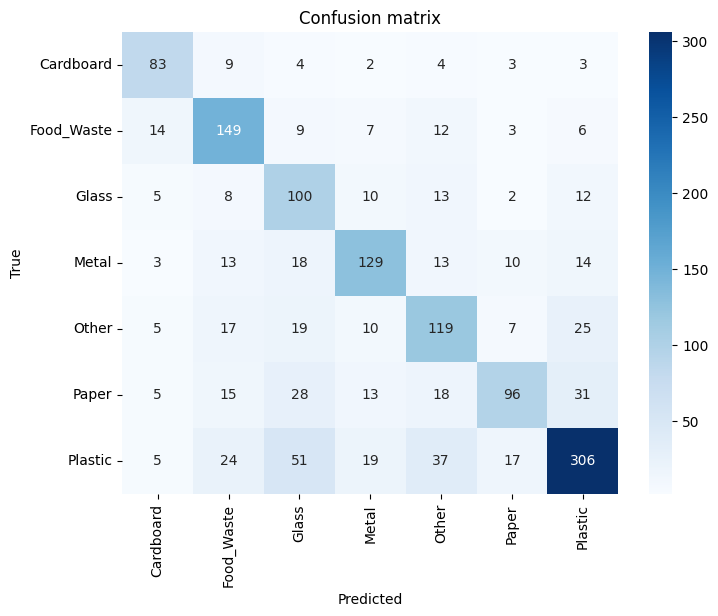

In [ ]:
# Evaluate on the test set; display suitable metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Evaluate on validation (test) set
test_loss, test_acc = model.evaluate(X_val, Y_val, verbose = 1)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

# Predictions
Y_pred = model.predict(X_val)
Y_pred_classes = np.argmax(Y_pred, axis = 1)
Y_true = np.argmax(Y_val, axis = 1)

# Classification Report
print("Classification Report:\n")
print(classification_report(Y_true, Y_pred_classes, target_names=Label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(Y_true, Y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = Label_encoder.classes_,
            yticklabels = Label_encoder.classes_)
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
# Define augmentation steps to augment images
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define agumentation pipeline
datagen = ImageDataGenerator(
    rotation_range = 20,       # Random rotation
    width_shift_range = 0.1,   # Horizontal shift
    height_shift_range = 0.1,   # vertical shift
    shear_range = 0.2,         # Shearing transformations
    zoom_range = 0.2,          # zoom in/ out
    horizontal_flip = True,    # flip image horizontally
    fill_mode = 'nearest'      # Fill missing pixels after transformation
)

# Fit the generator to training data
datagen.fit(X_train)







Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images
def augment_images(X, Y, augment_factor = 2):
  augmented_images, augmented_labels = [], []
  for i in range(len(X)):
    img = X[i].reshape((1,) + X[i].shape)
    for _ in range(augment_factor):
      for batch in datagen.flow(img, batch_size = 1):
        augmented_images.append(batch[0])
        augmented_labels.append(Y[i])
        break
  return np.array(augmented_images), np.array(augmented_labels)

  # Example usage: augment minority class (e.g., "Glass")
minority_idx = np.where(np.argmax(Y_train, axis=1) == 2)[0]  # class index 2
X_minority, Y_minority = X_train[minority_idx], Y_train[minority_idx]

X_aug, Y_aug = augment_images(X_minority, Y_minority, augment_factor=3)

# Combine augmented data back into training set
X_train_balanced = np.concatenate([X_train, X_aug])
Y_train_balanced = np.concatenate([Y_train, Y_aug])

print("Balanced training set:", X_train_balanced.shape, Y_train_balanced.shape)

Balanced training set: (7900, 128, 128, 3) (7900, 7)


In [ ]:
# Create the augmented training dataset
# Example: augment minority class (e.g., "Glass" with index 2)
minority_idx = np.where(np.argmax(Y_train, axis=1) == 2)[0]
X_minority, Y_minority = X_train[minority_idx], Y_train[minority_idx]

# Generate augmented samples
X_aug, Y_aug = augment_images(X_minority, Y_minority, augment_factor=3)

# Combine augmented data back into training set
X_train_augmented = np.concatenate([X_train, X_aug])
Y_train_augmented = np.concatenate([Y_train, Y_aug])

print("Augmented training set:", X_train_augmented.shape, Y_train_augmented.shape)


Augmented training set: (7900, 128, 128, 3) (7900, 7)


##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images

# Train the model
history = model.fit(
    X_train, Y_train,
    epochs = 30,
    batch_size = 32,
    validation_data = (X_val, Y_val),
    callbacks = [early_stop, checkpoint, reduce_lr],
    verbose = 1
)


## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

#__Initial dataset__
- The dataset contained images across 7 categories: Cardboard, Food Waste, Glass, Metal, Other, Paper, Plastic.

- There was noticeable class imbalance, with some categories (like Glass and Other) underrepresented compared to Plastic and Paper.


#__Data cleaning approach__

- Images were resized to a consistent shape for CNN input.

- Labels were encoded into integers and one‑hot vectors.

- Dataset was split into training and validation sets to ensure unbiased evaluation.


#__Challenges faced__

- Frequent syntax and import errors during preprocessing.

- Version conflicts between TensorFlow, Keras, and supporting libraries.

- Handling imbalanced classes required augmentation and undersampling strategies.


#__Training approach__

- Built a CNN with 3 convolutional layers, followed by pooling and dense layers.

- Applied data augmentation (rotation, shifts, flips, zoom) to improve generalization.

- Used callbacks like early stopping, checkpoints, and learning rate reduction to stabilize training.


#__Model performance__

- Test Accuracy: ~64%

- Test Loss: ~1.14

- Classification report showed stronger performance on majority classes (Plastic, Paper) but weaker recall on minority classes (Glass, Other).

- Confusion matrix revealed misclassifications between visually similar categories (e.g., Cardboard vs Paper).


#__Overall insights__

- Data imbalance was the biggest hurdle; augmentation helped but didn’t fully solve it.

- The CNN learned meaningful features but struggled with fine distinctions between similar waste categories.

- Future improvements could include transfer learning with pretrained models (e.g., ResNet, EfficientNet) and better dataset balancing.